# 10 – Selección de Modelo

Este notebook compara múltiples modelos de regresión para predecir **produccion_kg**.

Incluye:

- manejo de variables numéricas y categóricas
- imputación automática de valores faltantes
- comparación de múltiples modelos
- selección del mejor modelo según RMSE


## 1. Librerías


In [128]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


## 2. Cargar dataset con features


In [129]:
DATA_PATH = "../data/processed/training_dataset_features.parquet"

df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (9814, 82)


,cow_id,date,produccion_kg,ubre,destino_leche,ms,source_file,days_in_milk,lactation_age,weekday,month,group_id,pressure_msl,eventos_pdf_count,eventos_pdf_text,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,kg_consumido_por_vaca,promedio_corral,sobrante_pct,consumo_pct,diet_period,n_ingredientes,diet_dm_total,diet_wet_total,diet_pct_ms_total,usa_oro_milk,usa_oro_balance,usa_silo_maiz,usa_silo_avena,usa_ensilado,usa_heno,usa_triticale,usa_melaza,mes_merge,anio,mes,dia_mes,dia_semana,es_fin_de_semana,dia_del_anio,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos,produccion_lag_1,produccion_lag_2,produccion_lag_3,produccion_lag_7,delta_produccion_1d,delta_produccion_3d,produccion_roll_mean_3,produccion_roll_mean_7,produccion_roll_std_3,produccion_roll_std_7,kg_am_lag_1,kg_am_roll_mean_3,kg_pm_lag_1,kg_pm_roll_mean_3,kg_totales_lag_1,kg_totales_roll_mean_3,sobrante_lag_1,sobrante_roll_mean_3,consumo_lag_1,consumo_roll_mean_3,rechazo_lag_1,rechazo_roll_mean_3,kg_consumido_por_vaca_lag_1,kg_consumido_por_vaca_roll_mean_3,promedio_corral_lag_1,promedio_corral_roll_mean_3,sobrante_pct_lag_1,sobrante_pct_roll_mean_3,consumo_pct_lag_1,consumo_pct_roll_mean_3,ratio_sobrante_consumo,ratio_consumo_oferta,ratio_sobrante_oferta
0,1204,2025-01-01,16.68,0,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,1019.283333,<NA>,NaN,4000.0,4000.0,8000.0,10.0,7990.0,NaN,NaN,NaN,0.001282,0.998718,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01,2025,1,1,2,0,1,0.5,0.866025,0.974928,-0.222521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001252,0.998750,0.001250
1,1204,2025-01-02,17.91,1,Divert 3,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,1022.504167,<NA>,NaN,3950.0,3950.0,7900.0,710.0,7190.0,NaN,NaN,NaN,0.095335,0.904665,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01,2025,1,2,3,0,2,0.5,0.866025,0.433884,-0.900969,16.68,NaN,NaN,NaN,1.23,NaN,NaN,NaN,NaN,NaN,4000.0,NaN,4000.0,NaN,8000.0,NaN,10.0,NaN,7990.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001282,NaN,0.998718,NaN,0.098748,0.910127,0.089873
2,1204,2025-01-03,25.36,1,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,1023.987500,<NA>,NaN,3950.0,3900.0,7850.0,275.0,7575.0,NaN,NaN,NaN,0.035445,0.964555,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01,2025,1,3,4,0,3,0.5,0.866025,-0.433884,-0.900969,17.91,16.68,NaN,NaN,7.45,NaN,NaN,NaN,NaN,NaN,3950.0,NaN,3950.0,NaN,7900.0,NaN,710.0,NaN,7190.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.095335,NaN,0.904665,NaN,0.036304,0.964968,0.035032
3,1204,2025-01-04,16.71,1,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,1020.816667,<NA>,NaN,3950.0,3950.0,7900.0,395.0,7505.0,NaN,NaN,NaN,0.051798,0.948202,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01,2025,1,4,5,1,4,0.5,0.866025,-0.974928,-0.222521,25.36,17.91,16.68,NaN,-8.65,0.03,19.983333,NaN,4.696768,NaN,3950.0,3966.666667,3900.0,3950.000000,7850.0,7916.666667,275.0,331.666667,7575.0,7585.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.035445,0.044020,0.964555,0.955980,0.052632,0.950000,0.050000
4,1204,2025-01-05,25.04,1,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,1018.504167,<NA>,NaN,3950.0,3950.0,7900.0,505.0,7395.0,NaN,NaN,NaN,0.066472,0.933528,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01,2025,1,5,6,1,5,0.5,0.866025,-0.781831,0.623490,16.71,25.36,17.91,NaN,8.33,7.13,19.993333,NaN,4.686239,NaN,3950.0,3950.000000,3950.0,3933.333333,7900.0,7883.333333,395.0,460.000000,7505.0,7423.333333,NaN,NaN,NaN,NaN,NaN,NaN,0.051798,0.060859,0.948202,0.939141,0.068289,0.936076,0.063924


## 3. Definir variable objetivo y features


In [130]:
target = "produccion_kg"

selected_features = [

    # producción histórica
    "produccion_roll_mean_3",
    "produccion_roll_std_3",

    # cambios
    "delta_produccion_1d",
    "delta_produccion_3d",

    # alimentación
    "consumo",
    "consumo_roll_mean_3",
    "sobrante",
    "sobrante_roll_mean_3",
    "rechazo",
    "rechazo_roll_mean_3",
    "kg_am",
    "kg_pm",
    "kg_totales",

    # ratios
    "ratio_consumo_oferta",
    "ratio_sobrante_consumo",
    "ratio_sobrante_oferta",

    # dieta
    "n_ingredientes",
    "usa_oro_balance",
    "usa_silo_avena",
    "usa_triticale",

    # clima
    "pressure_msl",

    # tiempo
    "mes_sin",
    "mes_cos",
    "dia_semana_sin",
    "dia_semana_cos",
    "dia_del_anio",

    # categórica
    "ubre"
]


# Solo dejar columnas que existan
selected_features = [c for c in selected_features if c in df.columns]

# Orden temporal
df = df.sort_values("date").copy()

# Mantener solo features + target y quitar NaN
data = df[selected_features + [target]].dropna().copy()


### Comentarios y observaciones

En esta versión, las variables de alimentación ya forman parte del conjunto de features si están presentes en el dataset enriquecido.

Además, se eliminan explícitamente variables con fuga de información, para evitar resultados artificialmente perfectos.


## 4. Split temporal


In [131]:
# Split temporal
split_idx = int(len(data) * 0.8)

train = data.iloc[:split_idx].copy()
test = data.iloc[split_idx:].copy()

print("Train:", train.shape)
print("Test:", test.shape)


Train: (4836, 28)
Test: (1210, 28)


## 5. Construir matrices X y y


In [132]:
# X / y
X_train = train[selected_features].copy()
y_train = train[target].copy()

X_test = test[selected_features].copy()
y_test = test[target].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (4836, 27)
X_test: (1210, 27)


## 5.1 Cobertura de variables de alimentación en train y test

Antes de entrenar, conviene revisar cuántos valores faltantes tienen las variables de alimentación.


In [133]:
feeding_cols_model = [c for c in X_train.columns if any(
    token in c for token in [
        "kg_am", "kg_pm", "kg_totales", "sobrante", "consumo",
        "rechazo", "n_vacas", "kg_consumido_por_vaca",
        "promedio_corral", "kg_ofrecidos_por_vaca",
        "sobrante_pct", "consumo_pct",
        "ratio_sobrante", "ratio_consumo_oferta"
    ]
)]

if feeding_cols_model:
    print("NaN train:")
    display(X_train[feeding_cols_model].isna().mean().sort_values(ascending=False))
    print("NaN test:")
    display(X_test[feeding_cols_model].isna().mean().sort_values(ascending=False))
else:
    print("No se detectaron variables de alimentación en el set de entrenamiento.")


NaN train:


consumo                   0.0
consumo_roll_mean_3       0.0
sobrante                  0.0
sobrante_roll_mean_3      0.0
rechazo                   0.0
rechazo_roll_mean_3       0.0
kg_am                     0.0
kg_pm                     0.0
kg_totales                0.0
ratio_consumo_oferta      0.0
ratio_sobrante_consumo    0.0
ratio_sobrante_oferta     0.0
dtype: float64

NaN test:


consumo                   0.0
consumo_roll_mean_3       0.0
sobrante                  0.0
sobrante_roll_mean_3      0.0
rechazo                   0.0
rechazo_roll_mean_3       0.0
kg_am                     0.0
kg_pm                     0.0
kg_totales                0.0
ratio_consumo_oferta      0.0
ratio_sobrante_consumo    0.0
ratio_sobrante_oferta     0.0
dtype: float64

### Comentarios y observaciones

Las variables de alimentación pueden tener cobertura desigual entre meses, así que esta revisión ayuda a entender cuánto contexto real aportan en train y test.


## 6. Detectar columnas numéricas y categóricas


In [134]:
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", len(num_features))
print("Categóricas:", len(cat_features))

display(cat_features)


Numéricas: 27
Categóricas: 0


[]

## 7. Preprocesador con imputación


In [135]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)


## 8. Modelos a comparar


In [136]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "KNN": KNeighborsRegressor(n_neighbors=7)
}


## 9. Función de evaluación


In [137]:
def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


## 10. Entrenar y evaluar modelos


In [138]:
results = []
trained_models = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    pred = pipe.predict(X_test)
    
    mae, rmse, r2 = evaluar(y_test, pred)
    
    results.append({
        "Modelo": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    trained_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

display(results_df)


,Modelo,MAE,RMSE,R2
0,GradientBoosting,2.307317,2.944695,0.924263
1,ExtraTrees,2.241192,2.957148,0.923621
2,RandomForest,2.300874,3.019236,0.920380
3,Lasso,2.405301,3.036566,0.919463
4,LinearRegression,2.407578,3.039261,0.919320
5,Ridge,2.407776,3.039564,0.919304
6,KNN,4.413656,5.715462,0.714680


## 11. Visualizar comparación de modelos


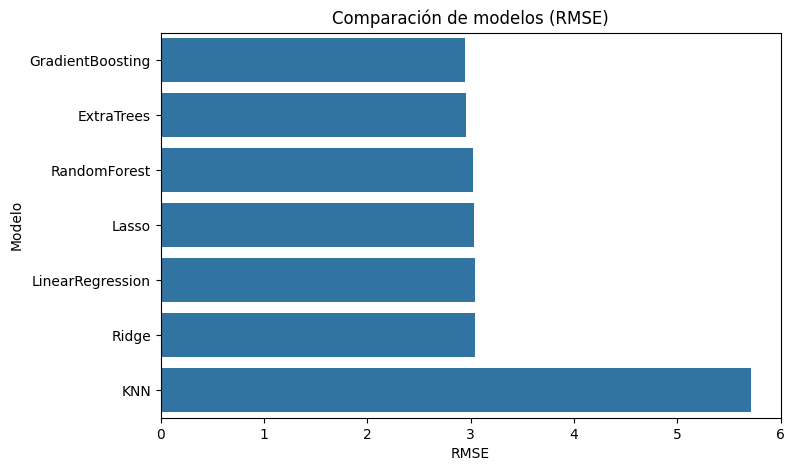

In [139]:
plt.figure(figsize=(8,5))

sns.barplot(data=results_df, x="RMSE", y="Modelo")

plt.title("Comparación de modelos (RMSE)")
plt.show()


## 12. Seleccionar mejor modelo


In [140]:
best_row = results_df.iloc[0]

best_model_name = best_row["Modelo"]
best_model = trained_models[best_model_name]

print("Mejor modelo encontrado:")
display(best_row)


Mejor modelo encontrado:


Modelo    GradientBoosting
MAE               2.307317
RMSE              2.944695
R2                0.924263
Name: 0, dtype: object

## 13. Real vs Predicho


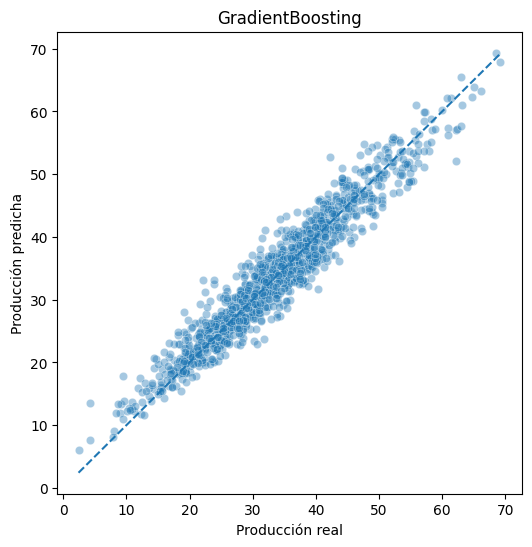

In [141]:
pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))

sns.scatterplot(x=y_test, y=pred, alpha=0.4)

plt.xlabel("Producción real")
plt.ylabel("Producción predicha")

min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title(best_model_name)

plt.show()


## 14. Conclusión

El modelo con menor **RMSE** se selecciona como el mejor modelo inicial.

En esta versión ya se consideran:

- variables temporales
- variables categóricas
- imputación de NaN
- variables de alimentación
- eliminación de variables con fuga de información

Pasos siguientes recomendados:

- ajuste de hiperparámetros
- validación temporal
- análisis de importancia de variables
- comparación explícita con y sin alimentación
